In [2]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

This rule is equivalent to itself.


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{488,464}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

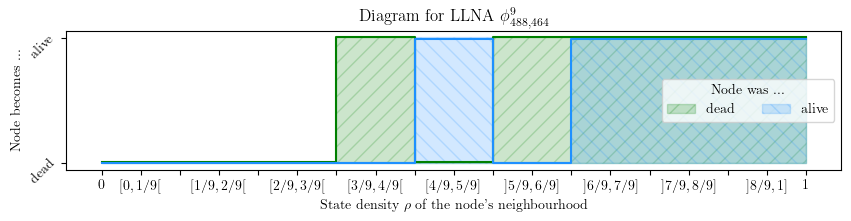

In [3]:
resolution = 9
beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

Text(0.5, 0.98, 'Rule $\\phi^9_{488,464}$')

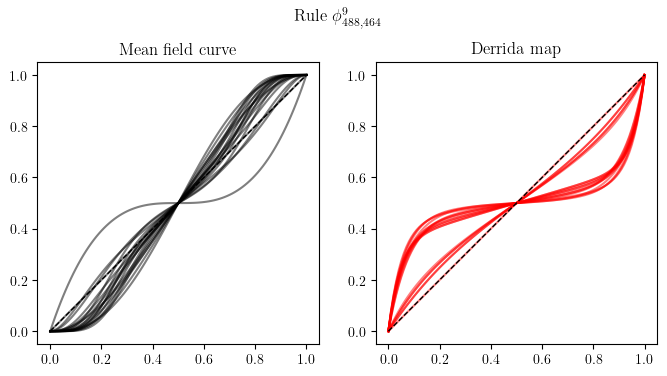

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

rho0_array = np.linspace(0,1,101)
delta0_array = np.linspace(0,1,101)
degrees= np.arange(1,20,1, dtype=int)

rho1_arrays = np.array([mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree) for degree in degrees])
delta1_arrays = np.array([derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree) for degree in degrees])

for degree, rho1_array, degree1_array in zip(degrees, rho1_arrays, delta1_arrays):
    axs[0].set_title("Mean field curve")
    axs[0].plot(rho0_array, rho1_array, label=f"Degree {degree}", color='k', alpha=0.5)
    axs[1].set_title("Derrida map")
    axs[1].plot(delta0_array, degree1_array, label=f"Degree {degree}", color='r', alpha=0.5)
for ax in axs:
    ax.plot([0,1], [0,1], lw=1, ls='--', color='k')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect(1)

plt.suptitle(f"Rule $\\phi^{resolution}_{{{beta},{sigma}}}$")

In [7]:
# Parameters
width = 100                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges) # watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

In [ ]:
idx = 1
edge = edges[idx]
graph_name = graph_names[idx]

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 10
init_dens = 0.5

init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)

# put back in L x L shape 
configs = configs.reshape((num_config, T+1, width, width))

In [9]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib import rcParams
rcParams['animation.embed_limit'] = 256  # Set a higher limit for embedding animations

def make_animation_object(grids, title=None):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        ax.set_title(title, fontsize=20)
        ax.set_xticks([]); ax.set_yticks([])
        return [im]
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [12]:
# show an animation. small world blijft krioelen voor day&night! random ook.
# threshold model wordt heel saai voor small world en voor random network, dus er is wel degelijk iets te zeggen voor het annealed model

example_idx = 0
ani = make_animation_object(configs[example_idx], title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [ ]:
# save some GIFs for future reference

SAVEGIFS = False
life_like_name = '488-464'

if SAVEGIFS:
    for i, config in tqdm(enumerate(configs), total=configs.shape[0]):
        savename = f"animation_llna_smallworld_{life_like_name}_{width}x{width}_T{T}_sample{i}.gif"

        # example_idx = np.random.randint(num_config)
        ani = make_animation_object(config, title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
        # ani = make_animation_object(defects[example_idx])

        # Save animations as GIFs
        loc = '../figures/gifs/'
        ani.save(loc+savename, writer='pillow', fps=24)  # Using Pillow

        # show inline
        # HTML(ani.to_jshtml())

100%|██████████| 10/10 [01:13<00:00,  7.31s/it]


# Introducing defects for tipping the scales

### First for a single initial configuration

In [235]:
# check the final density of the configurations. It should be either 0 or 1.
idx = 1
config = configs[idx]
print(f"The final state density is {np.mean(config[-1])}.")

The final state density is 0.0.


In [236]:
# flatten initial configuration
init_config = config[0].reshape(width**2)

# obtain degrees
degrees = np.array(graphs[1].degree())
sorted_indices = np.argsort(degrees)

# find and report max degrees
max_degree = np.max(degrees)
max_degree_indices = np.where(degrees == max_degree)[0]
max_degree_alive = np.sum(init_config[max_degree_indices])
almost_max_degree_indices = np.where(degrees == max_degree-1)[0]
almost_max_degree_alive = np.sum(init_config[almost_max_degree_indices])
print(f"There are {np.sum(degrees == max_degree)} nodes with the maximum degree {max_degree}. {max_degree_alive} are alive.")
print(f"There are {np.sum(degrees == max_degree-1)} nodes with the degree {max_degree-1}. {almost_max_degree_alive} are alive.")
print(f"")

min_degree = np.min(degrees)
min_degree_indices = np.where(degrees == min_degree)[0]
min_degree_alive = np.sum(init_config[min_degree_indices])
almost_min_degree_indices = np.where(degrees == min_degree+1)[0]
almost_min_degree_alive = np.sum(init_config[almost_min_degree_indices])
print(f"There are {np.sum(degrees == min_degree)} nodes with the minimum degree {min_degree}. {min_degree_alive} are alive.")
print(f"There are {np.sum(degrees == min_degree+1)} nodes with the degree {min_degree+1}. {almost_min_degree_alive} are alive.")

There are 3 nodes with the maximum degree 13. 1 are alive.
There are 36 nodes with the degree 12. 17 are alive.

There are 10 nodes with the minimum degree 4. 6 are alive.
There are 92 nodes with the degree 5. 47 are alive.


In [237]:
def switch_life_to_high_degree(graph, init_config, number_of_switches):
    if number_of_switches<0:
        raise ValueError(f"The number of switches must be a nutural number. Not {number_of_switches}.")
    # get all degrees
    degrees = np.array(graph.degree())
    N = len(init_config)
    if len(degrees) != N:
        raise ValueError(f"The number of nodes and the number of initial states do not match.")
    # get the indices of all nodes sorted by degree
    sorted_node_indices = np.argsort(degrees)
    sorted_degrees = degrees[sorted_node_indices]
    # find unique degrees
    unique_degrees = np.unique(degrees)
    # Randomize within groups (to avoid other correlations)
    shuffled_sorted_node_indices = np.empty_like(sorted_node_indices)
    start = 0
    for unique_degree in unique_degrees:
        # find where the indices correspond to the current degree value
        val_indices = np.where(sorted_degrees == unique_degree)[0]
        # get the subarray of degrees coresponding to this value
        group = sorted_node_indices[val_indices]
        # randomise the group
        np.random.shuffle(group)
        # glue the pieces back together
        shuffled_sorted_node_indices[start:start + len(group)] = group
        start += len(group)
    # order the initial configuration according to the shuffled degree-sorted indices
    init_config_shuffle_ordered = init_config[shuffled_sorted_node_indices]
    # find the shuffled indices whose node is alive and kill 'em dead
    indices_where_alive = np.where(init_config_shuffle_ordered==1)[0][:number_of_switches]
    init_config_shuffle_ordered[indices_where_alive] = 0
    # same for the high-degree dead nodes that are brought to life
    indices_where_dead  = np.where(init_config_shuffle_ordered==0)[0]
    number_of_dead = len(indices_where_dead)
    indices_where_dead = indices_where_dead[(number_of_dead-number_of_switches):]
    init_config_shuffle_ordered[indices_where_dead] = 1
    # undo the ordering
    init_config_switched = init_config_shuffle_ordered[np.argsort(shuffled_sorted_node_indices)]
    return init_config_switched

In [240]:
graph = graphs[1]

init_config_stack = init_config.copy()
for number_of_switches in tqdm(range(1000), total=1000):
    init_config_switched = switch_life_to_high_degree(graph, init_config, number_of_switches)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

100%|██████████| 1000/1000 [00:07<00:00, 139.19it/s]


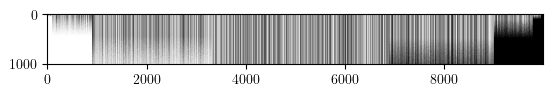

In [239]:
degrees = np.array(graphs[1].degree())
sorted_node_indices = np.argsort(degrees)

plt.imshow(init_config_stack[:,sorted_node_indices], cmap='Greys')

In [241]:
# run with new initial condition

edge = edges[1] # small-world
T = 100
num_new_runs = 100

configs_switched = model.forward(edge, tc.tensor(init_config_stack[:num_new_runs]), T=T).numpy().astype(int)

# put back in L x L shape 
configs_switched = configs_switched.reshape((num_new_runs, T+1, width, width))

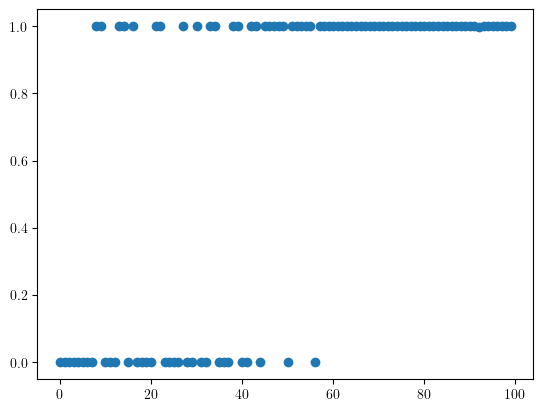

In [242]:
plt.scatter(range(100), np.mean(configs_switched[:,-1], axis=(1,2)))